<a href="https://colab.research.google.com/github/vmonreve/Kevin-Mawuntu_21210126/blob/main/Skripsi_Kevin%20Mawuntu_21210126.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT PACKAGE

In [ ]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.5 MB/s eta 0:00:00


In [ ]:
# Library untuk pengolahan data dan teks
import pandas as pd
import re
import numpy as np

# Library untuk visualisasi data
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Library machine learning (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Library NLP
import nltk
nltk.download('punkt')

# Library preprocessing Bahasa Indonesia (Sastrawi)
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Membaca dataset dari Google Drive
df = pd.read_csv('/content/drive/My Drive/SVM/datafix.csv', index_col=0)
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str
Source.Name,,,,,,,,,,,,,,
scrap_AI_Tools (1).csv,1.990000e+18,Sun Nov 09 10:40:57 +0000 2025,0,Dengan adanya AI ini jadi lebih gampang bikin ...,1.990000e+18,NaN,NaN,in,NaN,0,0,1,https://x.com/undefined/status/198747046097263...,3.238564e+07
scrap_AI_Tools (1).csv,1.970000e+18,Wed Sep 10 09:55:22 +0000 2025,2,lu bayangin deh muka lo diedit aneh aneh sama ...,1.970000e+18,NaN,NaN,in,NaN,0,0,1,https://x.com/undefined/status/196571571721667...,1.130000e+18
scrap_AI_Tools (1).csv,2.020000e+18,Thu Feb 05 03:33:37 +0000 2026,0,AI tools lagi booming banget apalagi bisa memb...,2.020000e+18,https://pbs.twimg.com/media/HAXT8eqacAgBbUo.jpg,NaN,in,NaN,1,0,0,https://x.com/undefined/status/201925305007934...,2.380631e+08
scrap_AI_Tools (1).csv,2.010000e+18,Wed Jan 21 16:08:19 +0000 2026,0,Sedang belajar banyak tools Ai untuk tingkatin...,2.010000e+18,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/201400715863592...,1.560000e+18
scrap_AI_Tools (1).csv,2.010000e+18,Wed Jan 21 06:11:47 +0000 2026,0,@davidsunarna Setuju. AI itu kita jadikan tool...,2.010000e+18,NaN,davidsunarna,in,NaN,0,0,0,https://x.com/undefined/status/201385703673633...,1.467623e+09


In [ ]:
# Mengambil hanya kolom 'full_text' dari dataset
df = df[['full_text']]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3531 entries, scrap_AI_Tools (1).csv to scrap_Meta_AI (1).csv
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3531 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


In [ ]:
# Mengganti nilai 'false' menjadi NA (missing value)
df['full_text'] = df['full_text'].replace('false', pd.NA)

# Menghapus baris yang memiliki nilai kosong pada kolom 'full_text'
df = df.dropna(subset=['full_text'])

# Menghapus baris yang masih memiliki nilai 'false'
df = df[df['full_text'] != 'false']

# Menghapus data duplikat berdasarkan kolom 'full_text'
df = df.drop_duplicates(subset=['full_text'])

# Menghapus semua baris yang masih memiliki nilai kosong
df = df.dropna()

In [ ]:
# Fungsi untuk membersihkan teks dari elemen tidak penting
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+',' ',text)
    text = re.sub(r'#\w+',' ',text)
    text = re.sub(r'RT[\s]+',' ',text)
    text = re.sub(r'https?://\S+',' ', text)
    text = re.sub(r'[^A-Za-z0-9 ]',' ', text)
    text = re.sub(r'\s+',' ', text).strip()
    return text

# Menerapkan fungsi cleaning ke kolom 'full_text'
df['full_text'] = df['full_text'].apply(clean_twitter_text)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3483 entries, scrap_AI_Tools (1).csv to scrap_Meta_AI (1).csv
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3483 non-null   object
dtypes: object(1)
memory usage: 54.4+ KB


In [ ]:
df.head(20)

,full_text
Source.Name,
scrap_AI_Tools (1).csv,Dengan adanya AI ini jadi lebih gampang bikin ...
scrap_AI_Tools (1).csv,lu bayangin deh muka lo diedit aneh aneh sama ...
scrap_AI_Tools (1).csv,AI tools lagi booming banget apalagi bisa memb...
scrap_AI_Tools (1).csv,Sedang belajar banyak tools Ai untuk tingkatin...
scrap_AI_Tools (1).csv,Setuju AI itu kita jadikan tools utk membantu ...
scrap_AI_Tools (1).csv,ai emang tools buat jahat lebih gampang jir
scrap_AI_Tools (1).csv,Menarik sih pakai AI buat efisiensi tapi giman...
scrap_AI_Tools (1).csv,Skrg tuh makin serem ga sih Foto kita yg udh d...
scrap_AI_Tools (1).csv,Sekarang lo tau kalo AI udah mulai takeover ba...


In [ ]:
# Case Folding
# Mengubah semua teks menjadi huruf kecil
df['full_text'] = df['full_text'].astype(str).str.lower()

In [ ]:
df.head(20)

,full_text
Source.Name,
scrap_AI_Tools (1).csv,dengan adanya ai ini jadi lebih gampang bikin ...
scrap_AI_Tools (1).csv,lu bayangin deh muka lo diedit aneh aneh sama ...
scrap_AI_Tools (1).csv,ai tools lagi booming banget apalagi bisa memb...
scrap_AI_Tools (1).csv,sedang belajar banyak tools ai untuk tingkatin...
scrap_AI_Tools (1).csv,setuju ai itu kita jadikan tools utk membantu ...
scrap_AI_Tools (1).csv,ai emang tools buat jahat lebih gampang jir
scrap_AI_Tools (1).csv,menarik sih pakai ai buat efisiensi tapi giman...
scrap_AI_Tools (1).csv,skrg tuh makin serem ga sih foto kita yg udh d...
scrap_AI_Tools (1).csv,sekarang lo tau kalo ai udah mulai takeover ba...


In [ ]:
# Normalisasi
# ====== Baca kamus kata tidak baku ======
kamus_data = pd.read_excel("kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))


# ====== Fungsi untuk Normalisasi kata ======
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()

        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]

                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
                else:
                    replaced_words.append(word)
            else:
                replaced_words.append(word)

        replaced_text = " ".join(replaced_words)

    else:
        replaced_text = ""
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []
    # Mengembalikan hasil normalisasi dan informasi tambahan
    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash


# ====== Menerapkan normalisasi ke kolom 'full_text' ======
df['full_text'], df['Kata_Baku'], df['Kata_Tidak_Baku'], df['Kata_Tidak_Baku_Hash'] = zip(
    *df['full_text'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku))
)



In [ ]:
df.head(20)

,full_text,Kata_Baku,Kata_Tidak_Baku,Kata_Tidak_Baku_Hash
Source.Name,,,,
scrap_AI_Tools (1).csv,dengan adanya ai ini jadi lebih gampang bikin ...,[],[],[]
scrap_AI_Tools (1).csv,kamu bayangkan deh muka lo diedit aneh aneh sa...,"[kamu, bayangkan, tidak, memang, sudah, saja]","[lu, bayangin, gak, emang, udah, aja]","[9149672256254449173, 1552715582905306454, 140..."
scrap_AI_Tools (1).csv,ai tools lagi booming banget apalagi bisa memb...,[],[],[]
scrap_AI_Tools (1).csv,sedang belajar banyak tools ai untuk tingkatin...,[],[],[]
scrap_AI_Tools (1).csv,setuju ai itu kita jadikan tools untuk membant...,[untuk],[utk],[239405239815939330]
scrap_AI_Tools (1).csv,ai memang tools buat jahat lebih gampang jir,[memang],[emang],[8674257242593153189]
scrap_AI_Tools (1).csv,menarik sih pakai ai buat efisiensi tapi bagai...,"[bagaimana, tidak]","[gimana, nggak]","[-6617705854921496987, -3353484815947853951]"
scrap_AI_Tools (1).csv,sekarang tuh makin seram tidak sih foto kita y...,"[sekarang, seram, tidak, yang, sudah, dengan, ...","[skrg, serem, ga, yg, udh, dgn, pake, aja, yg,...","[-8597872965370000827, 793082367104593921, 334..."
scrap_AI_Tools (1).csv,sekarang lo tau kalau ai sudah mulai takeover ...,"[kalau, sudah, pekerjaan, pakai, pakai]","[kalo, udah, kerjaan, pake, pake]","[-7884107731030929053, 7576375856303082074, -8..."


In [ ]:
# tokenized
# Memecah teks menjadi token (kata per kata)
tokenized = df['full_text'].apply(lambda x: x.split())
tokenized.head()

,full_text
Source.Name,
scrap_AI_Tools (1).csv,"[dengan, adanya, ai, ini, jadi, lebih, gampang..."
scrap_AI_Tools (1).csv,"[kamu, bayangkan, deh, muka, lo, diedit, aneh,..."
scrap_AI_Tools (1).csv,"[ai, tools, lagi, booming, banget, apalagi, bi..."
scrap_AI_Tools (1).csv,"[sedang, belajar, banyak, tools, ai, untuk, ti..."
scrap_AI_Tools (1).csv,"[setuju, ai, itu, kita, jadikan, tools, untuk,..."


In [ ]:
print(tokenized.iloc[9])

['tools', 'ai', 'sudah', 'jadi', 'wajib', 'banget', 'sekarang', 'chatgpt', 'sama', 'canva', 'bener2', 'membantu', 'banget', 'buat', 'pekerjaan', 'bulanan', 'lebih', 'masuk', 'akal', 'sih', 'daripada', 'bayar', 'setahun', 'langsung']


In [ ]:
df.head(20)

,full_text,Kata_Baku,Kata_Tidak_Baku,Kata_Tidak_Baku_Hash
Source.Name,,,,
scrap_AI_Tools (1).csv,dengan adanya ai ini jadi lebih gampang bikin ...,[],[],[]
scrap_AI_Tools (1).csv,kamu bayangkan deh muka lo diedit aneh aneh sa...,"[kamu, bayangkan, tidak, memang, sudah, saja]","[lu, bayangin, gak, emang, udah, aja]","[9149672256254449173, 1552715582905306454, 140..."
scrap_AI_Tools (1).csv,ai tools lagi booming banget apalagi bisa memb...,[],[],[]
scrap_AI_Tools (1).csv,sedang belajar banyak tools ai untuk tingkatin...,[],[],[]
scrap_AI_Tools (1).csv,setuju ai itu kita jadikan tools untuk membant...,[untuk],[utk],[239405239815939330]
scrap_AI_Tools (1).csv,ai memang tools buat jahat lebih gampang jir,[memang],[emang],[8674257242593153189]
scrap_AI_Tools (1).csv,menarik sih pakai ai buat efisiensi tapi bagai...,"[bagaimana, tidak]","[gimana, nggak]","[-6617705854921496987, -3353484815947853951]"
scrap_AI_Tools (1).csv,sekarang tuh makin seram tidak sih foto kita y...,"[sekarang, seram, tidak, yang, sudah, dengan, ...","[skrg, serem, ga, yg, udh, dgn, pake, aja, yg,...","[-8597872965370000827, 793082367104593921, 334..."
scrap_AI_Tools (1).csv,sekarang lo tau kalau ai sudah mulai takeover ...,"[kalau, sudah, pekerjaan, pakai, pakai]","[kalo, udah, kerjaan, pake, pake]","[-7884107731030929053, 7576375856303082074, -8..."


In [ ]:
# Stopwords
# Mengimpor library Sastrawi untuk stopword removal
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary

# Menambahkan stopword tambahan
more_stop_words = []

# Mengambil daftar stopword bawaan
stop_words = StopWordRemoverFactory().get_stop_words()
stop_words.extend(more_stop_words)

# Membuat objek stopword remover
new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

# Fungsi untuk menghapus stopword dari teks
def stopword(str_text):
    str_text = stop_words_remover_new.remove(str_text)
    return str_text

# Menerapkan stopword removal ke kolom 'full_text'
df['full_text'] = df['full_text'].apply(lambda x: stopword(x))
df.head()


,full_text,Kata_Baku,Kata_Tidak_Baku,Kata_Tidak_Baku_Hash
Source.Name,,,,
scrap_AI_Tools (1).csv,adanya ai jadi lebih gampang bikin internal to...,[],[],[]
scrap_AI_Tools (1).csv,kamu bayangkan deh muka lo diedit aneh aneh sa...,"[kamu, bayangkan, tidak, memang, sudah, saja]","[lu, bayangin, gak, emang, udah, aja]","[9149672256254449173, 1552715582905306454, 140..."
scrap_AI_Tools (1).csv,ai tools booming banget bisa membantu kesehari...,[],[],[]
scrap_AI_Tools (1).csv,sedang belajar banyak tools ai tingkatin kiner...,[],[],[]
scrap_AI_Tools (1).csv,setuju ai jadikan tools membantu kerja lebih e...,[untuk],[utk],[239405239815939330]


In [ ]:
# Stemming
# Mengimpor stemmer dari Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Fungsi untuk melakukan stemming
def stemming(text_cleaning):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    do = []
    for w in text_cleaning:
        dt = stemmer.stem(w)
        do.append(dt)
    d_clean = []
    d_clean = " ".join(do)
    print(d_clean)
    return d_clean

# Menerapkan stemming pada data tokenized
tokenized = tokenized.apply(stemming)
# Menyimpan hasil stemming ke file CSV di Google Drive
tokenized.to_csv('/content/drive/My Drive/SVM/hasildatafix.csv', index=False)


dengan ada ai ini jadi lebih gampang bikin internal tools untuk mudah kerja
kamu bayang deh muka lo edit aneh aneh sama orang pakai ai apa tidak murka ya memang tanpa ai dulu juga sudah bisa saja dimanip dengan tools macam macam tapi butuh skill sekarang semua orang bisa dengan mudah gonta ganti muka dan badan lo
ai tools lagi booming banget apalagi bisa bantu dalam hari contoh dalam dunia sehat jadi efisiensi diagnosis lebih cepat kurang beban tenaga medis dan dukung layan seperti homecare nursing
sedang ajar banyak tools ai untuk tingkatin kerja tim sales amp marketing
tuju ai itu kita jadi tools untuk bantu agar kerja kita lebih efisien misal kita bisa ajar ai agents mana yang bisa bantu kita kerja lebih efisien dan lebih efektif
ai memang tools buat jahat lebih gampang jir
tarik sih pakai ai buat efisiensi tapi bagaimana dengan orisinalitas dan diferensiasi brand ke depan kalau banyak bisnis pakai tools ai yang sama apa tidak risiko konten jadi mirip mirip dan susah tonjol di pasar

In [ ]:
# Membaca hasil data stemming dari file CSV di Google Drive
df = pd.read_csv('/content/drive/My Drive/SVM/hasildatafix.csv')
df.head()

,full_text
0,dengan ada ai ini jadi lebih gampang bikin int...
1,kamu bayang deh muka lo edit aneh aneh sama or...
2,ai tools lagi booming banget apalagi bisa bant...
3,sedang ajar banyak tools ai untuk tingkatin ke...
4,tuju ai itu kita jadi tools untuk bantu agar k...


In [ ]:
# Membaca dataset dari Google Drive
df = pd.read_csv('/content/drive/My Drive/SVM/hasildatafix.csv')

# Membaca kamus leksikon positif dan negatif
positive_lexicon = set(pd.read_csv("positive.tsv", sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv("negative.tsv", sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen berdasarkan jumlah kata positif dan negatif
def determine_sentiment(text):
    positive_count = sum(1 for word in text.split() if word in positive_lexicon)
    negative_count = sum(1 for word in text.split() if word in negative_lexicon)
    if positive_count > negative_count:
        return "Positif"
    elif positive_count < negative_count:
        return "Negatif"
    else:
        return None

# Menerapkan fungsi sentimen ke kolom 'full_text'
df['Sentiment'] = df['full_text'].apply(determine_sentiment)

# Fungsi untuk mengganti None pada label
def replace_none_sentiment(sentiments):
    replace_flag = "Positif"
    for i in range(len(sentiments)):
        if sentiments[i] is None:
            sentiments[i] = replace_flag
            replace_flag = "Negatif" if replace_flag == "Positif" else "Positif"
    return sentiments

# Mengganti nilai None pada label sentimen
df['Sentiment'] = replace_none_sentiment(df['Sentiment'].tolist())

# Melihat hasil
df.head()


,full_text,Sentiment
0,dengan ada ai ini jadi lebih gampang bikin int...,Positif
1,kamu bayang deh muka lo edit aneh aneh sama or...,Negatif
2,ai tools lagi booming banget apalagi bisa bant...,Positif
3,sedang ajar banyak tools ai untuk tingkatin ke...,Positif
4,tuju ai itu kita jadi tools untuk bantu agar k...,Positif


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

In [ ]:
# Menghitung jumlah masing-masing label sentimen
sentimen_counts = df['Sentiment'].value_counts()
sentimen_counts

,count
Sentiment,
Positif,1821
Negatif,1662


/tmp/ipykernel_7483/4194699917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='Set1')


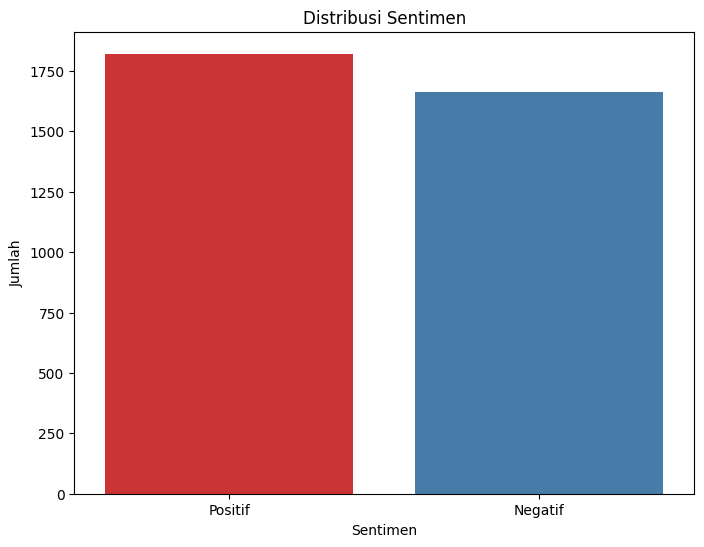

In [ ]:
# Membuat ukuran gambar
plt.figure(figsize=(8, 6))

# Membuat grafik countplot untuk distribusi sentimen
sns.countplot(x='Sentiment', data=df, palette='Set1')

# Menambahkan judul dan label sumbu
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

plt.show()


In [ ]:
# Mengambil data full_text sebagai fitur (x)
x = df.full_text

# Mengambil label sentimen sebagai target (y)
y = df.Sentiment


In [ ]:
# Membagi data menjadi data training (80%) dan testing (20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Menampilkan jumlah data training dan testing
print("Jumlah data training :", len(x_train))
print("Jumlah data testing  :", len(x_test))

Jumlah data training : 2786
Jumlah data testing  : 697


In [ ]:
# Membuat objek TF-IDF Vectorizer
tvec = TfidfVectorizer()

# Mengubah data teks menjadi fitur numerik menggunakan TF-IDF
X_tfidf = tvec.fit_transform(df['full_text'])

In [ ]:
# Mengubah hasil TF-IDF menjadi DataFrame
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tvec.get_feature_names_out()
)

In [ ]:
# Mengambil nilai TF-IDF pada data ke-10
kalimat9 = tfidf_df.iloc[9]

In [ ]:
# Menampilkan hanya kata yang memiliki nilai TF-IDF > 0 pada data ke-10
kalimat9[kalimat9 > 0]

,9
ai,0.067111
akal,0.325732
banget,0.318916
bantu,0.167933
bayar,0.239331
bener2,0.316339
buat,0.122673
bulan,0.203710
canva,0.216415
chatgpt,0.097847


In [ ]:
# Membuat model SVM dengan kernel RBF
clf_svm = SVC(kernel='rbf')

# Membuat pipeline (TF-IDF + SVM)
model_svm = Pipeline([('vectorizer', tvec), ('classifier', clf_svm)])

# Melatih model menggunakan data training
model_svm = model_svm.fit(x_train, y_train)

# Melakukan prediksi pada data testing
hasil_svm = model_svm.predict(x_test)

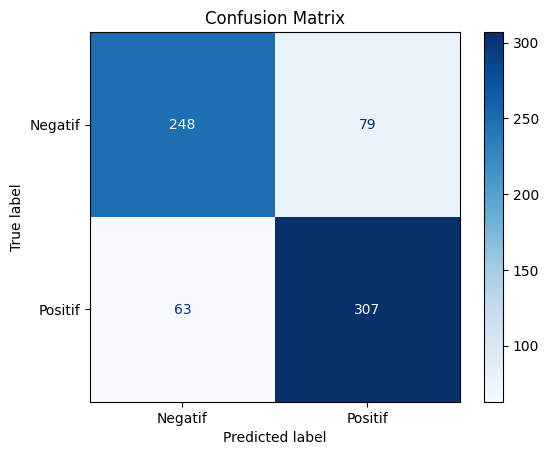

In [ ]:
# Membuat confusion matrix dari hasil prediksi
cm = confusion_matrix(y_test, hasil_svm)

# Menampilkan confusion matrix dalam bentuk visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_svm.classes_)
disp.plot(cmap='Blues')

# Menambahkan judul dan menampilkan grafik
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Membuat classification report untuk evaluasi model
matrix = classification_report(y_test, hasil_svm)

# Menampilkan hasil evaluasi (precision, recall, f1-score, accuracy)
print("Classification report : \n", matrix)


Classification report : 
               precision    recall  f1-score   support

     Negatif       0.80      0.76      0.78       327
     Positif       0.80      0.83      0.81       370

    accuracy                           0.80       697
   macro avg       0.80      0.79      0.79       697
weighted avg       0.80      0.80      0.80       697



Parsed - Negatif: [0.8, 0.76, 0.78], Positif: [0.8, 0.83, 0.81]


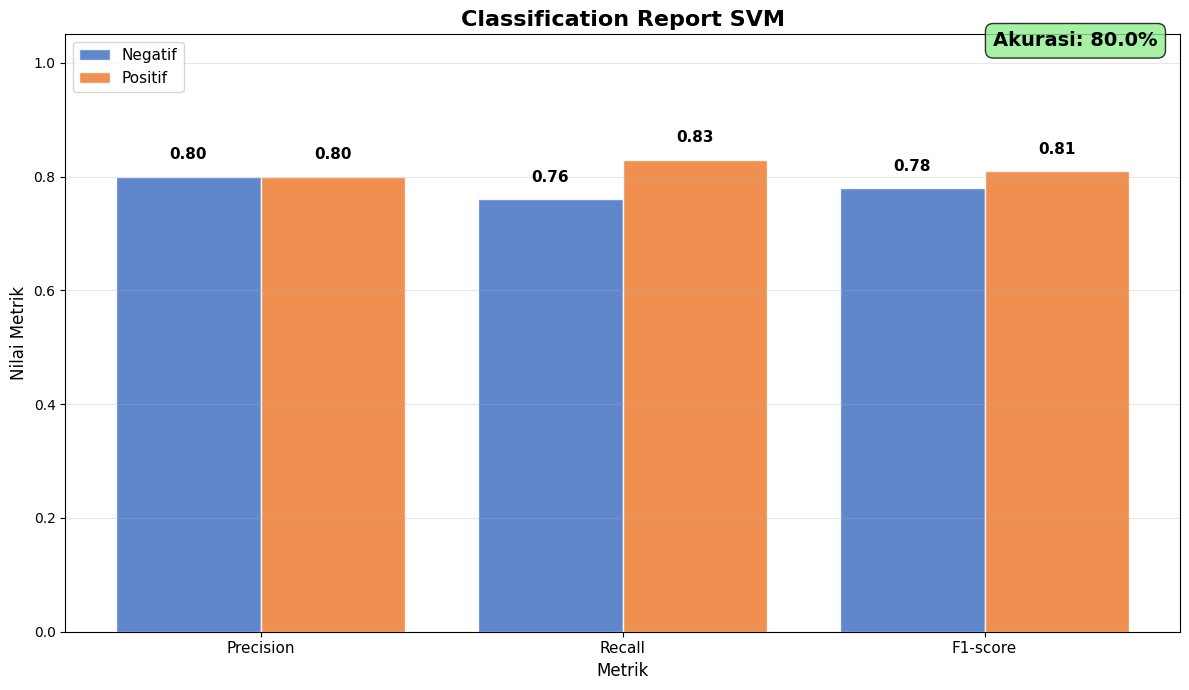

In [ ]:
# Fungsi untuk memvisualisasikan classification report dalam bentuk grafik
def plot_classification_report(report_text):
    # Memisahkan teks report menjadi baris
    lines = report_text.split('\n')
    data = {'Negatif': [], 'Positif': []}

    # Mengambil nilai precision, recall, f1-score dari masing-masing kelas
    for line in lines:
        line = line.strip()
        floats = re.findall(r'\b\d+\.\d+\b', line)

        if 'Negatif' in line and len(floats) >= 3:
            data['Negatif'] = [float(x) for x in floats[:3]]
        elif 'Positif' in line and len(floats) >= 3:
            data['Positif'] = [float(x) for x in floats[:3]]

    # Cek apakah data berhasil diambil
    if not data['Negatif'] or not data['Positif']:
        print("Error: Tidak bisa parse data. Contoh output report:")
        print(report_text[:200])
        return

    negatif = data['Negatif']
    positif = data['Positif']
    print(f"Parsed - Negatif: {negatif}, Positif: {positif}")

    # Membuat grafik batang untuk precision, recall, f1-score
    fig, ax = plt.subplots(figsize=(12, 7))
    categories = ['Precision', 'Recall', 'F1-score']
    x = np.arange(3)
    width = 0.4

    # Membuat bar chart untuk kelas negatif dan positif menjadi berwarna
    bars1 = ax.bar(x-width/2, negatif, width, label='Negatif', color='#4472C4', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x+width/2, positif, width, label='Positif', color='#ED7D31', alpha=0.85, edgecolor='white')

    # Menambahkan judul dan label
    ax.set_title('Classification Report SVM', fontweight='bold', fontsize=16)
    ax.set_ylabel('Nilai Metrik', fontsize=12)
    ax.set_xlabel('Metrik', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.legend(loc='upper left', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

    # Menampilkan nilai pada setiap bar
    for i, (n, p) in enumerate(zip(negatif, positif)):
        ax.text(i-width/2, n+0.025, f'{n:.2f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
        ax.text(i+width/2, p+0.025, f'{p:.2f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

    # Mengambil dan menampilkan nilai akurasi
    accuracy_line = [line for line in lines if 'accuracy' in line.lower()]
    if accuracy_line:
        acc_match = re.search(r'(\d+\.\d+)', accuracy_line[0])
        if acc_match:
            accuracy = float(acc_match.group(1))
            ax.text(0.98, 0.98, f'Akurasi: {accuracy:.1%}', transform=ax.transAxes,
                   fontsize=14, fontweight='bold', ha='right',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.8))

    # Menampilkan dan menyimpan grafik
    plt.tight_layout()
    plt.savefig('svm_report_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()

# Mengambil classification report dan memvisualisasikannya
report = classification_report(y_test, hasil_svm, output_dict=False)
plot_classification_report(report)


IMPORT DATA

CLEANING DATA

PROCESSING TEXT

LABELING

TRAIN DATA

KLASIFIKASI SVM